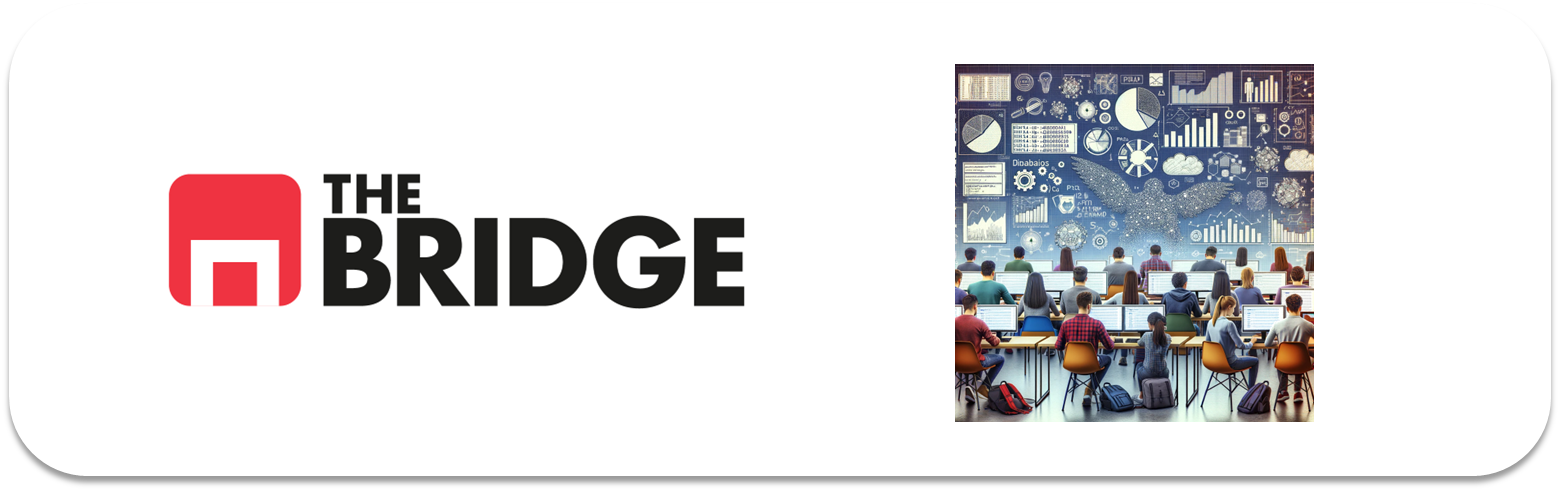

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay,
)

def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas."""
    candidatas = [os.path.join(directorio_inicio, nombre)]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta
    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)
    return None

ruta_bootcamp = buscar_fichero("bootcampviztools.py")
if ruta_bootcamp is None:
    raise FileNotFoundError(
        "No se ha encontrado 'bootcampviztools.py'. Colócalo en la misma carpeta "
        "que este notebook o en cualquier subcarpeta suya."
    )

sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
print("bootcampviztools.py encontrado en:", ruta_bootcamp)

# Funciones de apoyo para el mini-EDA (aportadas por el bootcamp)
from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_categorical_relationship_fin,
    plot_categorical_numerical_relationship,
    plot_combined_graphs,
)

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
np.random.seed(42)


bootcampviztools.py encontrado en: .\bootcampviztools.py


### 1. Carga del dataset del Titanic

In [2]:
def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas,
    para no depender de una ruta absoluta fija en el equipo de cada uno."""
    candidatas = [
        os.path.join(directorio_inicio, nombre),
        os.path.join(directorio_inicio, "data", nombre),
    ]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta

    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)

    return None

ruta_titanic = buscar_fichero("titanic.csv")
if ruta_titanic is None:
    raise FileNotFoundError(
        "No se ha encontrado 'titanic.csv'. Colócalo en la misma carpeta que este "
        "notebook o en cualquier subcarpeta suya (p.ej. 'data/titanic.csv')."
    )

print("Cargando dataset desde:", ruta_titanic)
df = pd.read_csv(ruta_titanic)
df.shape


Cargando dataset desde: .\data\titanic.csv


(891, 15)

In [3]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


### 2. Nos deshacemos de las variables que no vamos a usar

El dataset trae varias columnas redundantes o derivadas de otras (fuga de información /
duplicidad):

- `alive`: es exactamente `survived` pero en texto ("yes"/"no") -> la quitamos.
- `class`: es `pclass` pero en texto ("First"/"Second"/"Third") -> duplicada.
- `who`/`adult_male`: son variables derivadas de `sex` y `age`, no aportan nada nuevo.
- `embark_town`: es `embarked` pero con el nombre completo de la ciudad -> duplicada.
- `deck`: tiene un porcentaje enorme de nulos (más del 75%), así que la eliminamos
  directamente en vez de imputarla (el enunciado pide no imputar en este paso).

Nos quedamos con: `survived` (target), `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`,
`embarked`.

In [5]:
print("% de nulos por columna:")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))


% de nulos por columna:
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
sex             0.0
pclass          0.0
survived        0.0
fare            0.0
parch           0.0
sibsp           0.0
class           0.0
adult_male      0.0
who             0.0
alive           0.0
alone           0.0
dtype: float64


In [6]:
columnas_utiles = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df = df[columnas_utiles].copy()
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 3. Variable target: `survived`

Queremos predecir si un pasajero sobrevive o no, así que el target es `survived`
(0 = no sobrevive, 1 = sobrevive). Es un problema de **clasificación binaria**.

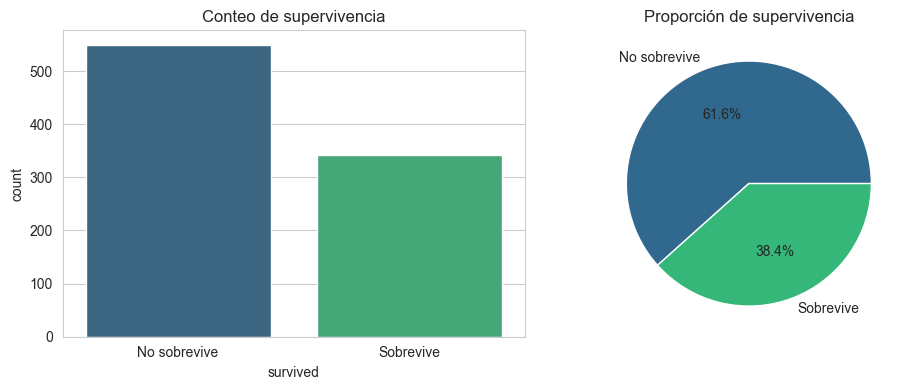

survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="survived", data=df, hue="survived", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Conteo de supervivencia")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No sobrevive", "Sobrevive"])

proporciones = df["survived"].value_counts(normalize=True) * 100
axes[1].pie(proporciones, labels=["No sobrevive", "Sobrevive"], autopct="%1.1f%%",
            colors=sns.color_palette("viridis", 2))
axes[1].set_title("Proporción de supervivencia")

plt.tight_layout()
plt.show()

print(df["survived"].value_counts(normalize=True).round(3))


Hay un **desbalance moderado** de clases: en torno al 62% no sobrevive y el 38% sobrevive.
No es un desbalance extremo (no haría falta técnicas de balanceo agresivas como SMOTE), pero
sí es suficiente para tener en cuenta que:

- Un modelo "tonto" que siempre prediga "no sobrevive" ya acertaría ~62% de las veces, así
  que **la accuracy sola no es una métrica fiable** para evaluar el modelo.
- Conviene mirar también **precision, recall, F1 y la curva ROC/AUC**, y prestar atención
  especialmente al recall de la clase minoritaria (sobrevive), que es probablemente la que
  más nos interesa detectar bien.

### 4. Split train / test

Se pide que ambos conjuntos tengan un reparto similar de pasajeros según el puerto de
embarque (`embarked`). Usamos `stratify` sobre esa columna. Como `embarked` tiene 2 valores
nulos, para poder estratificar rellenamos temporalmente esos huecos solo de cara al split
(con la moda), sin tocar todavía el dataframe real -- la imputación "de verdad" la haremos
más adelante, únicamente con estadísticos calculados sobre train.

In [8]:
moda_embarked_global = df["embarked"].mode()[0]
estratos = df["embarked"].fillna(moda_embarked_global)

train_set, test_set = train_test_split(
    df, test_size=0.2, random_state=42, stratify=estratos
)

print("Train:", train_set.shape, " Test:", test_set.shape)

print("\nReparto embarked en train:")
print(train_set["embarked"].value_counts(normalize=True).round(3))
print("\nReparto embarked en test:")
print(test_set["embarked"].value_counts(normalize=True).round(3))


Train: (712, 8)  Test: (179, 8)

Reparto embarked en train:
embarked
S    0.725
C    0.188
Q    0.087
Name: proportion, dtype: float64

Reparto embarked en test:
embarked
S    0.723
C    0.192
Q    0.085
Name: proportion, dtype: float64


### 5. Construcción de las parejas X, y

In [9]:
X_train = train_set.drop(columns=["survived"]).copy()
y_train = train_set["survived"].copy()

X_test = test_set.drop(columns=["survived"]).copy()
y_test = test_set["survived"].copy()

X_train.shape, X_test.shape


((712, 7), (179, 7))

### 6. Imputación de nulos

Calculamos la **media de `age`** y la **moda de `embarked`** únicamente con `X_train`, y
guardamos esos valores para aplicarlos también a test más adelante (así evitamos fuga de
información desde el test).

In [10]:
edad_media_train = X_train["age"].mean()
moda_embarked_train = X_train["embarked"].mode()[0]

print("Edad media (train):", round(edad_media_train, 2))
print("Moda de embarked (train):", moda_embarked_train)

X_train["age"] = X_train["age"].fillna(edad_media_train)
X_train["embarked"] = X_train["embarked"].fillna(moda_embarked_train)

X_train.isnull().sum()


Edad media (train): 30.18
Moda de embarked (train): S


pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

### 7. Mini-EDA y selección de features

Usamos las funciones de `bootcampviztools` para ver rápidamente cómo se relaciona cada
variable con la supervivencia.

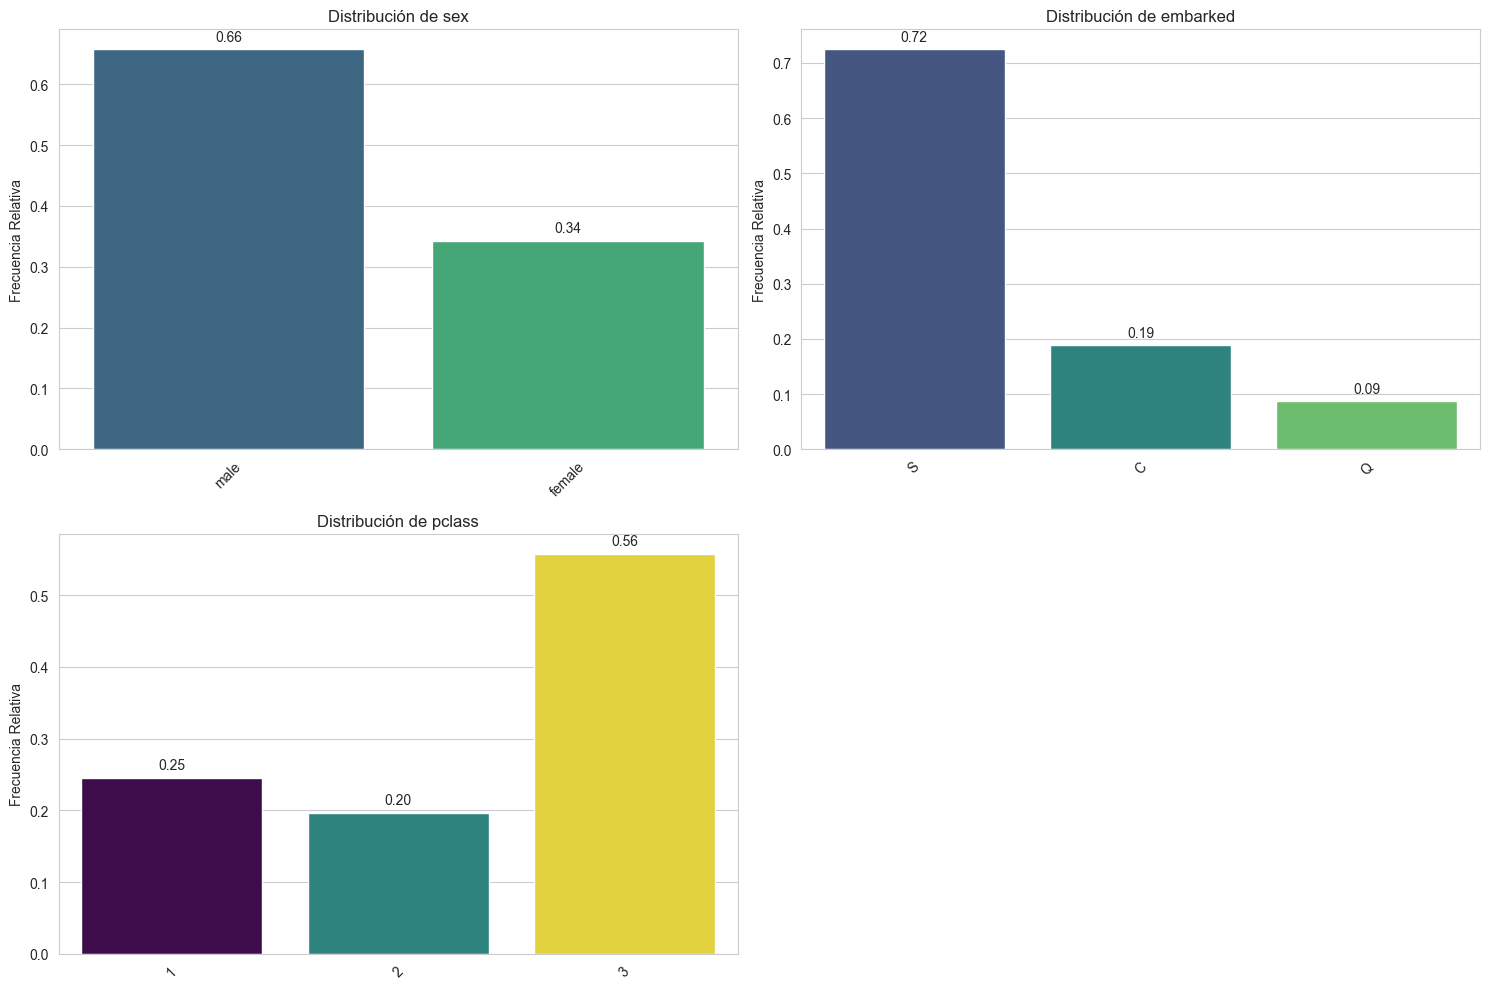

In [11]:
eda_train = X_train.copy()
eda_train["survived"] = y_train.values

pinta_distribucion_categoricas(eda_train, ["sex", "embarked", "pclass"], relativa=True, mostrar_valores=True)


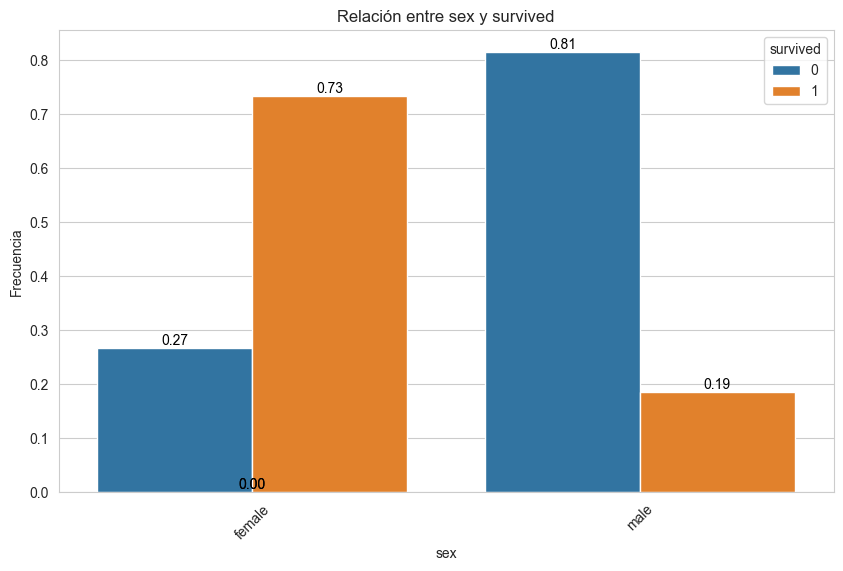

In [12]:
plot_categorical_relationship_fin(eda_train, "sex", "survived", relative_freq=True, show_values=True)


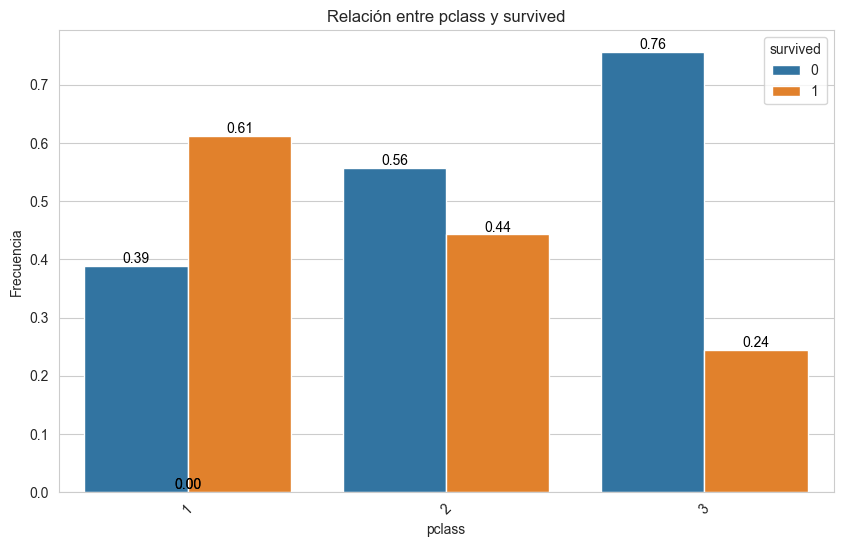

In [13]:
plot_categorical_relationship_fin(eda_train, "pclass", "survived", relative_freq=True, show_values=True)


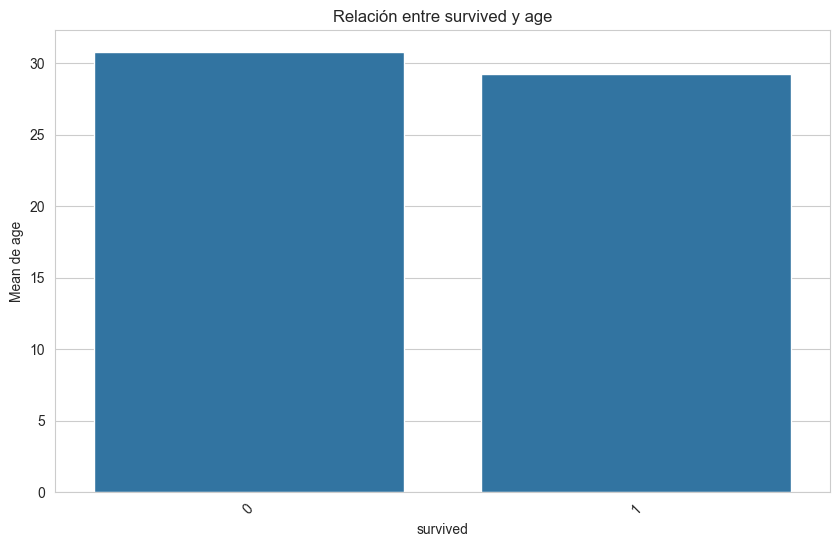

In [14]:
plot_categorical_numerical_relationship(eda_train, "survived", "age", measure="mean")


(2, 2)


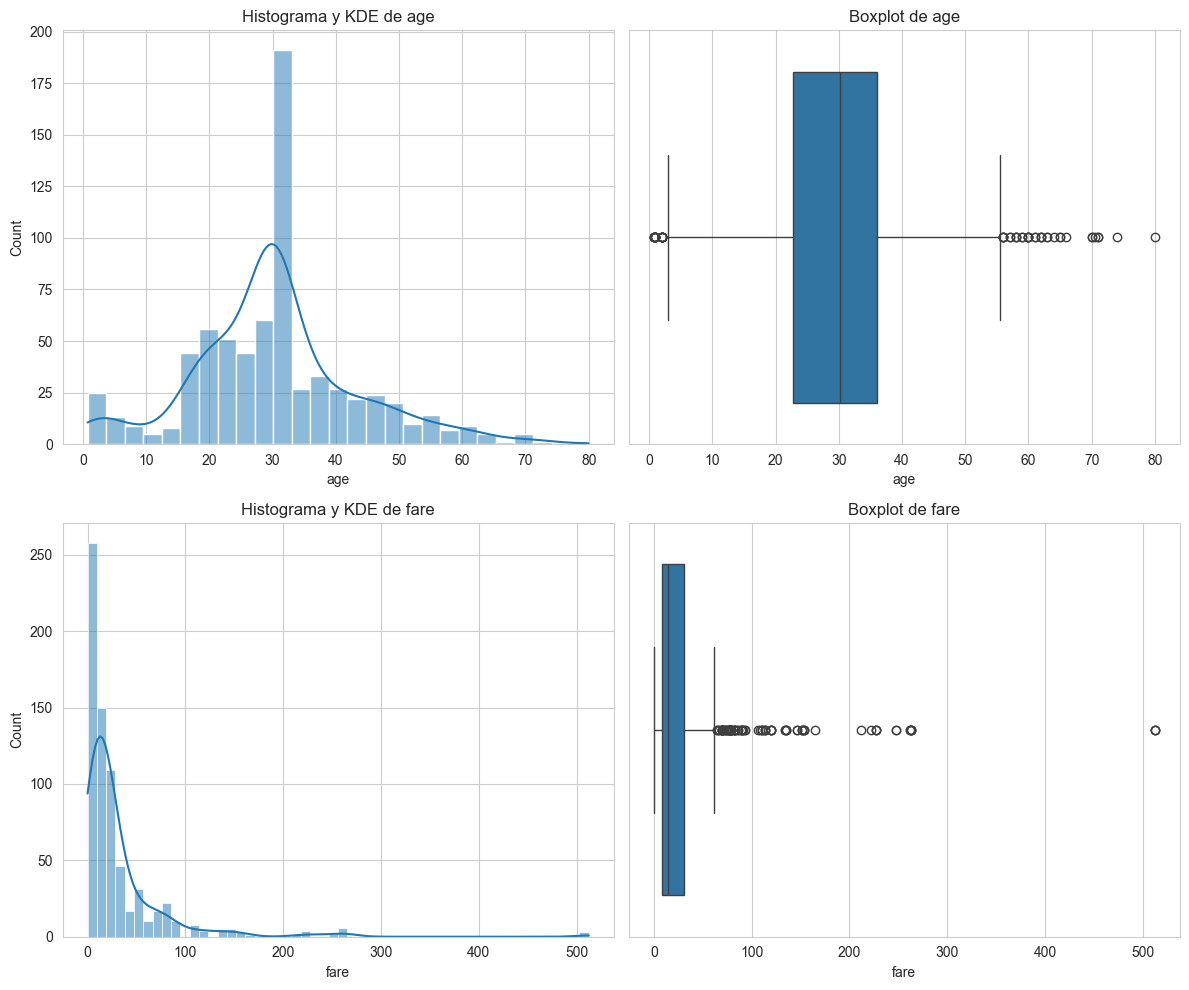

In [15]:
plot_combined_graphs(eda_train, ["age", "fare"])


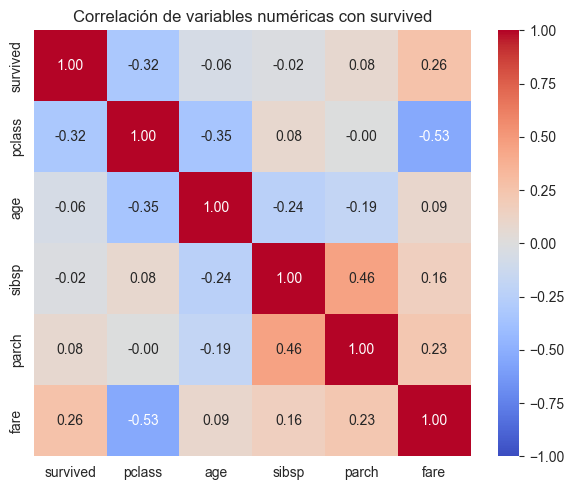

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(eda_train[["survived", "pclass", "age", "sibsp", "parch", "fare"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación de variables numéricas con survived")
plt.tight_layout()
plt.show()


**Conclusiones del mini-EDA:**

- `sex` es, de largo, la variable con relación más fuerte con `survived`: las mujeres
  sobreviven muchísimo más que los hombres. Es una feature clave.
- `pclass` también marca una diferencia grande: a mejor clase (1ª), mayor tasa de
  supervivencia.
- `age` tiene una relación más suave (los más jóvenes sobreviven algo más de media), pero
  aporta información.
- `fare` está bastante correlada con `pclass` (viajar en 1ª es más caro), pero no es
  perfectamente redundante, así que la mantenemos.
- `sibsp` y `parch` por separado aportan poco, pero juntas describen el tamaño de la
  familia a bordo, que sí parece influir (viajar completamente solo o en familias muy
  grandes se asocia a menor supervivencia) -> las combinamos en una única feature de tamaño
  de familia en el siguiente paso.

Nos quedamos con: `sex`, `pclass`, `age`, `fare`, `embarked`, y una nueva variable derivada
de `sibsp` + `parch`.

### 8. Tratamiento de variables

- Creamos `family_size = sibsp + parch + 1` y `is_alone` (1 si viaja solo).
- Codificamos `sex` como binaria (0 = male, 1 = female).
- Codificamos `embarked` con one-hot encoding (`drop_first=True` para evitar la trampa de
  las variables dummy).
- Escalamos `age` y `fare` con `StandardScaler`, ajustado únicamente sobre train.

In [17]:
def crear_features_familia(X):
    X = X.copy()
    X["family_size"] = X["sibsp"] + X["parch"] + 1
    X["is_alone"] = (X["family_size"] == 1).astype(int)
    return X.drop(columns=["sibsp", "parch"])

X_train = crear_features_familia(X_train)
X_train.head()


,pclass,sex,age,fare,embarked,family_size,is_alone
838,3,male,32.0,56.4958,S,1,1
621,1,male,42.0,52.5542,S,2,0
282,3,male,16.0,9.5000,S,1,1
275,1,female,63.0,77.9583,S,2,0
217,2,male,42.0,27.0000,S,2,0


In [18]:
X_train["sex"] = X_train["sex"].map({"male": 0, "female": 1})
X_train = pd.get_dummies(X_train, columns=["embarked"], drop_first=True)
X_train.head()


,pclass,sex,age,fare,family_size,is_alone,embarked_Q,embarked_S
838,3,0,32.0,56.4958,1,1,False,True
621,1,0,42.0,52.5542,2,0,False,True
282,3,0,16.0,9.5000,1,1,False,True
275,1,1,63.0,77.9583,2,0,False,True
217,2,0,42.0,27.0000,2,0,False,True


In [19]:
scaler = StandardScaler()
columnas_a_escalar = ["age", "fare"]
X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_train.head()


,pclass,sex,age,fare,family_size,is_alone,embarked_Q,embarked_S
838,3,0,0.138935,0.468278,1,1,False,True
621,1,0,0.904324,0.392016,2,0,False,True
282,3,0,-1.085687,-0.440992,1,1,False,True
275,1,1,2.511641,0.883533,2,0,False,True
217,2,0,0.904324,-0.102404,2,0,False,True


### 9. Modelo de regresión logística

In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Columnas usadas por el modelo:", list(X_train.columns))


Columnas usadas por el modelo: ['pclass', 'sex', 'age', 'fare', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S']


### 10. EXTRA: análisis de los pesos del modelo

Como `age` y `fare` están escaladas y el resto son binarias/ordinal pequeña, los
coeficientes son razonablemente comparables. Además, transformamos los coeficientes en
**odds ratios** (`exp(coef)`), que se interpretan de forma más intuitiva: cuánto se
multiplican las probabilidades relativas de sobrevivir por cada unidad de la variable.

In [21]:
coefs = pd.DataFrame({
    "feature": X_train.columns,
    "coeficiente": log_reg.coef_[0],
})
coefs["odds_ratio"] = np.exp(coefs["coeficiente"])
coefs = coefs.sort_values("coeficiente", key=np.abs, ascending=False).reset_index(drop=True)
coefs


,feature,coeficiente,odds_ratio
0,sex,2.413346,11.171275
1,pclass,-0.864054,0.421450
2,is_alone,-0.711578,0.490869
3,age,-0.407215,0.665501
4,family_size,-0.400826,0.669767
5,embarked_S,-0.317775,0.727766
6,embarked_Q,0.188335,1.207237
7,fare,0.185688,1.204046


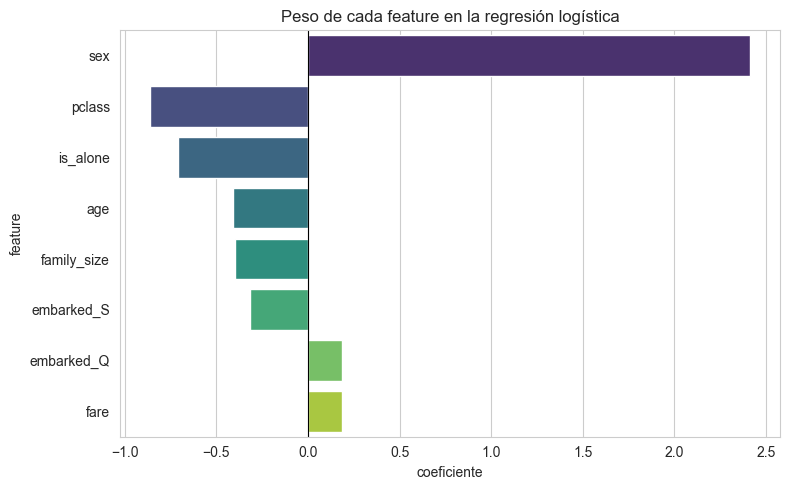

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=coefs, x="coeficiente", y="feature", hue="feature", palette="viridis", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Peso de cada feature en la regresión logística")
plt.tight_layout()
plt.show()


`sex` (ser mujer) es, con diferencia, el coeficiente más positivo: multiplica muchísimo
las probabilidades de sobrevivir, tal y como ya intuíamos en el EDA. `pclass` tiene
coeficiente negativo (a mayor número de clase, es decir, peor clase, menos probabilidad de
sobrevivir). `is_alone` y `family_size` aportan matices menores. Todo coherente con el
contexto histórico (mujeres y niños primero, y mejor trato en primera clase).

### 11. Procesamos el dataset de test

Aplicamos **exactamente las mismas transformaciones** que en train, pero usando los
estadísticos y objetos (`edad_media_train`, `moda_embarked_train`, `scaler`) ya ajustados
con train, y alineamos las columnas dummy para que test tenga las mismas que train.

In [23]:
X_test["age"] = X_test["age"].fillna(edad_media_train)
X_test["embarked"] = X_test["embarked"].fillna(moda_embarked_train)

X_test = crear_features_familia(X_test)
X_test["sex"] = X_test["sex"].map({"male": 0, "female": 1})
X_test = pd.get_dummies(X_test, columns=["embarked"], drop_first=True)

# Alineamos columnas por si en test faltase o sobrase alguna categoría dummy
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

X_test.head()


,pclass,sex,age,fare,family_size,is_alone,embarked_Q,embarked_S
395,3,0,-0.626454,-0.473965,1,1,False,True
557,1,0,0.000000,3.777336,1,1,False,False
563,3,0,0.000000,-0.469047,1,1,False,True
21,2,0,0.292013,-0.373275,1,1,False,True
444,3,0,0.000000,-0.467838,1,1,False,True


### 12. Evaluación del modelo

In [24]:
pred_train = log_reg.predict(X_train)
pred_test = log_reg.predict(X_test)

proba_train = log_reg.predict_proba(X_train)[:, 1]
proba_test = log_reg.predict_proba(X_test)[:, 1]

def resumen_metricas(y_true, y_pred, etiqueta=""):
    print(f"--- {etiqueta} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1       :", round(f1_score(y_true, y_pred), 3))
    print()

resumen_metricas(y_train, pred_train, "Train")
resumen_metricas(y_test, pred_test, "Test")

print("Classification report (test):")
print(classification_report(y_test, pred_test, target_names=["No sobrevive", "Sobrevive"]))


--- Train ---
Accuracy : 0.799
Precision: 0.762
Recall   : 0.673
F1       : 0.715

--- Test ---
Accuracy : 0.832
Precision: 0.829
Recall   : 0.763
F1       : 0.795

Classification report (test):
              precision    recall  f1-score   support

No sobrevive       0.83      0.88      0.86       103
   Sobrevive       0.83      0.76      0.79        76

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



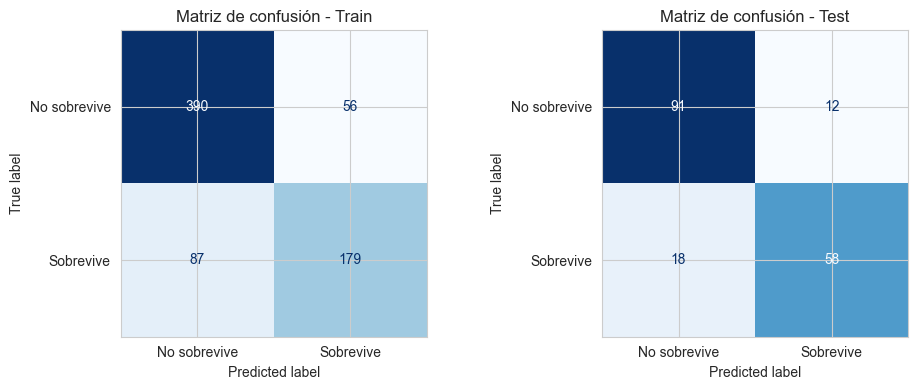

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_train, pred_train, display_labels=["No sobrevive", "Sobrevive"],
                                         cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión - Train")

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["No sobrevive", "Sobrevive"],
                                         cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de confusión - Test")

plt.tight_layout()
plt.show()


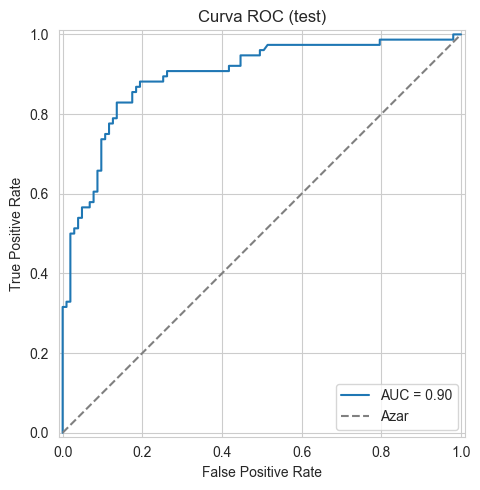

AUC test: 0.897


In [26]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc_test = roc_auc_score(y_test, proba_test)

plt.figure(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_test).plot(ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Azar")
plt.title("Curva ROC (test)")
plt.legend()
plt.tight_layout()
plt.show()

print("AUC test:", round(auc_test, 3))


**Assessment de generalización:** las métricas de train y test son muy parecidas
(accuracy y F1 con menos de un par de puntos de diferencia), y el AUC en test es claramente
superior a 0.5 (el azar). No hay señales claras de overfitting: el modelo generaliza bien a
datos que no ha visto. La matriz de confusión muestra que el modelo comete algo más de
error identificando supervivientes (falsos negativos) que identificando no supervivientes,
coherente con el desbalance de clases que vimos al principio.

### 13. EXTRA: probabilidad de supervivencia de un perfil concreto

Queremos la probabilidad de supervivencia de un **hombre de entre 30 y 40 años**, que
**embarcó en Southampton**, viajaba en **segunda clase**, **solo**, y **no pagó el billete**
(fare = 0).

Como la edad es un rango (30-40) y no un valor único, calculamos la probabilidad para cada
edad entera del rango y hacemos la media, tal y como sugiere la pista del enunciado.

In [27]:
edades_rango = list(range(30, 41))  # 30 a 40 inclusive

perfil_base = {
    "pclass": 2,
    "age": None,       # se rellena en el bucle
    "fare": 0,
    "family_size": 1,  # viaja solo -> family_size = 1
    "is_alone": 1,
    "sex": 0,          # male
    "embarked_Q": 0,
    "embarked_S": 1,   # Southampton (embarked_C es la categoría de referencia)
}

filas = []
for edad in edades_rango:
    fila = perfil_base.copy()
    fila["age"] = edad
    filas.append(fila)

perfil_df = pd.DataFrame(filas)[X_train.columns]  # mismo orden de columnas que en train
perfil_df[columnas_a_escalar] = scaler.transform(perfil_df[columnas_a_escalar])

probabilidades = log_reg.predict_proba(perfil_df)[:, 1]
for edad, p in zip(edades_rango, probabilidades):
    print(f"Edad {edad}: probabilidad de sobrevivir = {p:.3f}")

print("\nProbabilidad media de sobrevivir para el perfil (30-40 años):",
      round(probabilidades.mean(), 3))


Edad 30: probabilidad de sobrevivir = 0.201
Edad 31: probabilidad de sobrevivir = 0.196
Edad 32: probabilidad de sobrevivir = 0.191
Edad 33: probabilidad de sobrevivir = 0.186
Edad 34: probabilidad de sobrevivir = 0.182
Edad 35: probabilidad de sobrevivir = 0.177
Edad 36: probabilidad de sobrevivir = 0.172
Edad 37: probabilidad de sobrevivir = 0.168
Edad 38: probabilidad de sobrevivir = 0.164
Edad 39: probabilidad de sobrevivir = 0.160
Edad 40: probabilidad de sobrevivir = 0.155

Probabilidad media de sobrevivir para el perfil (30-40 años): 0.177


### 14. EXTRA: adaptación a un problema multiclase

Cambiamos el target: ahora queremos predecir la **clase del viajero** (`pclass`, que tiene 3
valores posibles: 1, 2, 3). Quitamos `pclass` de las features y añadimos `survived` (el
target anterior) como una feature más. El resto de features y del pipeline se mantiene
igual.

In [28]:
X_train_multi = X_train.drop(columns=["pclass"]).copy()
X_train_multi["survived"] = y_train.values
y_train_multi = train_set.loc[X_train.index, "pclass"].values if False else None
# pclass es la columna original de train_set (antes de quitarla de X_train en el paso 8)
y_train_multi = train_set["pclass"].values

X_test_multi = X_test.drop(columns=["pclass"]).copy()
X_test_multi["survived"] = y_test.values
y_test_multi = test_set["pclass"].values

X_train_multi.head()


,sex,age,fare,family_size,is_alone,embarked_Q,embarked_S,survived
838,0,0.138935,0.468278,1,1,False,True,1
621,0,0.904324,0.392016,2,0,False,True,1
282,0,-1.085687,-0.440992,1,1,False,True,0
275,1,2.511641,0.883533,2,0,False,True,1
217,0,0.904324,-0.102404,2,0,False,True,0


In [29]:
log_reg_multi = LogisticRegression(max_iter=1000, random_state=42)
log_reg_multi.fit(X_train_multi, y_train_multi)

pred_train_multi = log_reg_multi.predict(X_train_multi)
pred_test_multi = log_reg_multi.predict(X_test_multi)

print("Classification report - Train (target = pclass):")
print(classification_report(y_train_multi, pred_train_multi))

print("Classification report - Test (target = pclass):")
print(classification_report(y_test_multi, pred_test_multi))


Classification report - Train (target = pclass):
              precision    recall  f1-score   support

           1       0.90      0.93      0.91       175
           2       0.74      0.25      0.37       140
           3       0.79      0.96      0.87       397

    accuracy                           0.81       712
   macro avg       0.81      0.71      0.72       712
weighted avg       0.81      0.81      0.78       712

Classification report - Test (target = pclass):
              precision    recall  f1-score   support

           1       0.95      0.95      0.95        41
           2       0.83      0.34      0.48        44
           3       0.77      0.98      0.86        94

    accuracy                           0.82       179
   macro avg       0.85      0.76      0.76       179
weighted avg       0.83      0.82      0.79       179



El modelo multiclase también generaliza razonablemente bien (métricas parecidas en train
y test), aunque como era de esperar el rendimiento por clase es más heterogéneo que en el
problema binario original: al haber 3 clases el problema es intrínsecamente más difícil, y
es habitual que la clase intermedia (2ª clase) sea la que peor se predice, al ser la más
"ambigua" en términos de las features disponibles (tarifa, tamaño de familia, puerto de
embarque, etc.), quedando más solapada con la 1ª y la 3ª clase.

### Conclusiones

- La regresión logística consigue un buen ajuste al problema binario (survived), con
  métricas de train y test muy similares, señal de que generaliza bien.
- Las variables más determinantes son `sex` y `pclass`, muy por encima del resto,
  coherente con el contexto histórico del hundimiento.
- El modelo adaptado a multiclase (pclass) funciona razonablemente, aunque con más
  dificultad para distinguir la clase intermedia.